In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


### Charts' General Style

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)

# Set Up and Cleaning

In [ ]:
# Reading CSV file in a pandas DataFrame
df = pd.read_csv("aviation-accidents.csv")

In [ ]:
df.head()   # Visualize first 5 rows of the DataFrame

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


In [ ]:
df.tail()   # Visualize last 5 rows of the DataFrame

,date,type,registration,operator,fatalities,location,country,cat,year
23962,11-MAY-2023,Hawker 900XP,PK-LRU,Angkasa Super Services,0,Maleo Airport (MOH),Indonesia,A2,2023
23963,11-MAY-2023,Cessna 208B Grand Caravan,PK-NGA,Nasional Global Aviasi,0,Fentheik Airstrip,Indonesia,A2,2023
23964,12-MAY-2023,Cessna 208B Grand Caravan,5X-RBR,Bar Aviation,0,Kampala-Kajjansi...,Uganda,A1,2023
23965,14-MAY-2023,Boeing 747-4R7F,LX-OCV,Cargolux,0,Luxembourg-Finde...,Luxembourg,A2,2023
23966,15-MAY-2023,Learjet 35A,D-CGFQ,GFD,2,Hohn Air Base,Germany,A1,2023


In [ ]:
df.info()   # All columns read as strings

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [ ]:
# Improve formatting
# The column "date" contains values in format "11-MAY-2023" or "date unk."
# errors="coerce" transforms values not parsed in NaT
df["date_parsed"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")
# About season, from date parsed i extract the day of the week (ex. "Monday") and the month (1–12).
df["day_of_week"] = df["date_parsed"].dt.day_name()
df["month"]       = df["date_parsed"].dt.month
# The column "year" contains also the string "unknown", so i used errors="coerce"
# to transform those values in NaN (Not a Number) instead of making a new error.
# I do the same thing with column "fatalities".
df["year_num"]       = pd.to_numeric(df["year"],       errors="coerce")
df["fatalities_num"] = pd.to_numeric(df["fatalities"], errors="coerce")


# Improve tickets for categories
# Building a map dictionary and i use .map() to get
# english descriptions on the charts, this way there won't be any code as 'A1', 'C1', ecc... in the column 'cat'.
cat_map = {
    "A1": "Destroyed (accident)", "A2": "Damaged (accident)",
    "C1": "Destroyed (criminal)", "C2": "Damaged (criminal)",
    "H1": "Destroyed (danger)",  "H2": "Damaged (danger)",
    "O1": "Destroyed (other)",     "O2": "Damaged (other)",
    "U1": "Destroyed (unknown)",    "U2": "Damaged (unknown)",
    "I1": "Destroyed (fire)",  "I2": "Damaged (fire)",
}
df["cat_label"] = df["cat"].map(cat_map)




# Print clean dataset
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Years: {int(df['year_num'].min())} – {int(df['year_num'].max())}")
print(f"Total fatalities recorded: {df['fatalities_num'].sum():,.0f}")

Dataset: 23967 rows, 15 columns
Years: 1919 – 2023
Total fatalities recorded: 120,729




---



# 1) In which nations occurred the most amount of accidents?


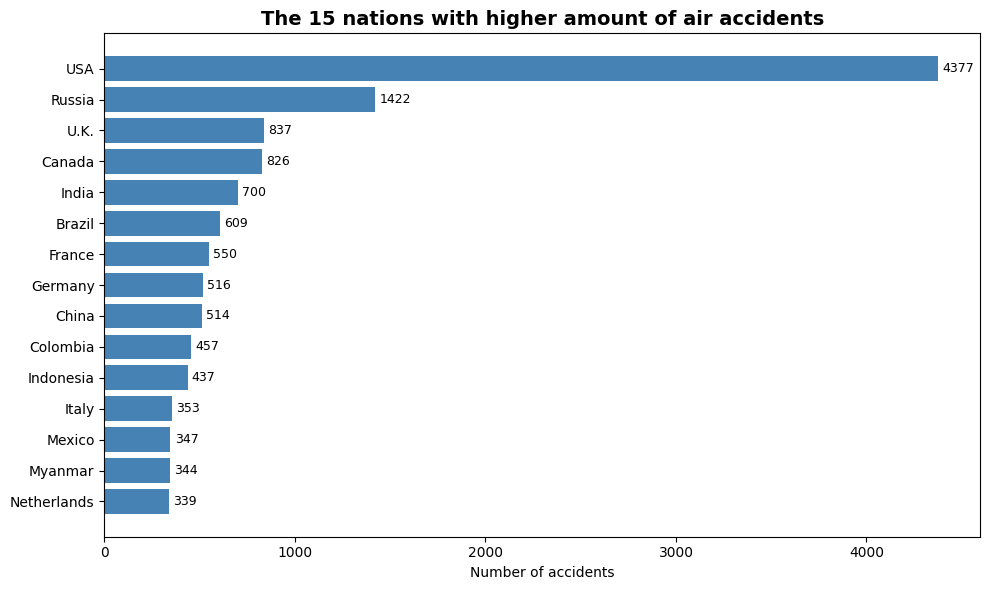

In [ ]:
# Count accidents per nation and exclude 'Unknown country', which isn't a real geographic data but a placeholder for missing values.
# .value_counts() already returns values in descending order.
countries_most_accidents = (df[df["country"] !="Unknown country"]
                            ["country"].value_counts().head(15))

# Build the chart
fig, ax = plt.subplots()
# Use a orizontal bar chart (barh) becausethe nations' names are longer and can be read in a better way on y axis.
# Invert the order with [::-1] to put the higher value on top of the chart.
bars = ax.barh(countries_most_accidents.index[::-1], countries_most_accidents.values[::-1], color="steelblue")

# bar_label automatically add the numeric value at the end of each bar.
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("The 15 nations with higher amount of air accidents", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of accidents")
plt.tight_layout()  # titles and labels won't be cut
plt.show()




---



#2) In which days of the week the accidents occur?

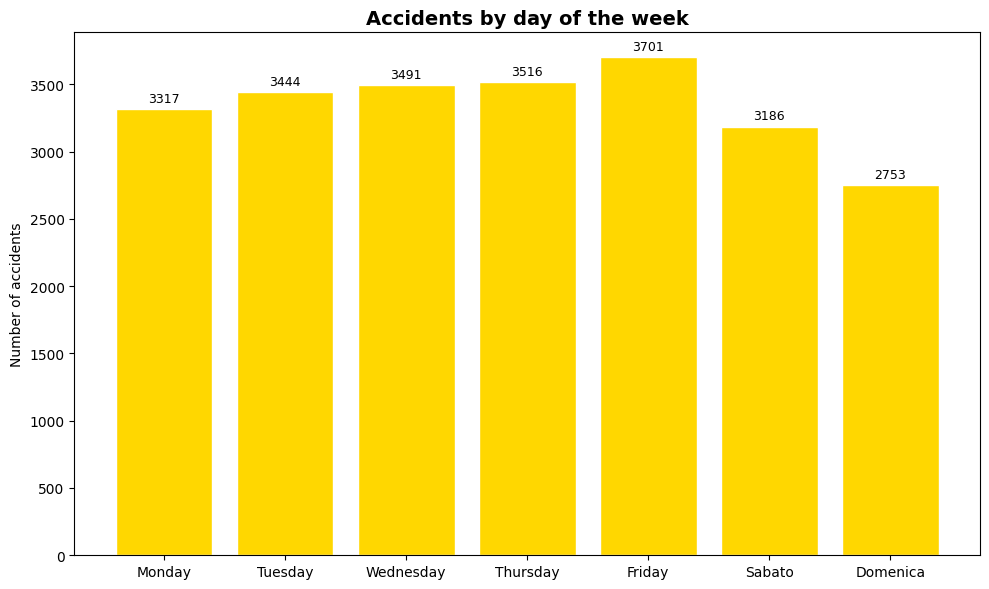

In [ ]:
# Define days order from monday to sunday, .value_counts() returns them in frequency order.
day_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_labels = ["Monday","Tuesday","Wednesday","Thursday","Friday","Sabato","Domenica"]

# .reindex(day_order) reorders the Serie by the list, days will appear in correct order on X axis.
day_counts = df["day_of_week"].value_counts().reindex(day_order)

# Build the chart
fig, ax = plt.subplots()
# Use the vertical bar chart (bar)
bars = ax.bar(day_labels, day_counts.values, color="gold", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Accidents by day of the week", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of accidents")
plt.tight_layout()
plt.show()



---



#3) Which are the safest airlines?

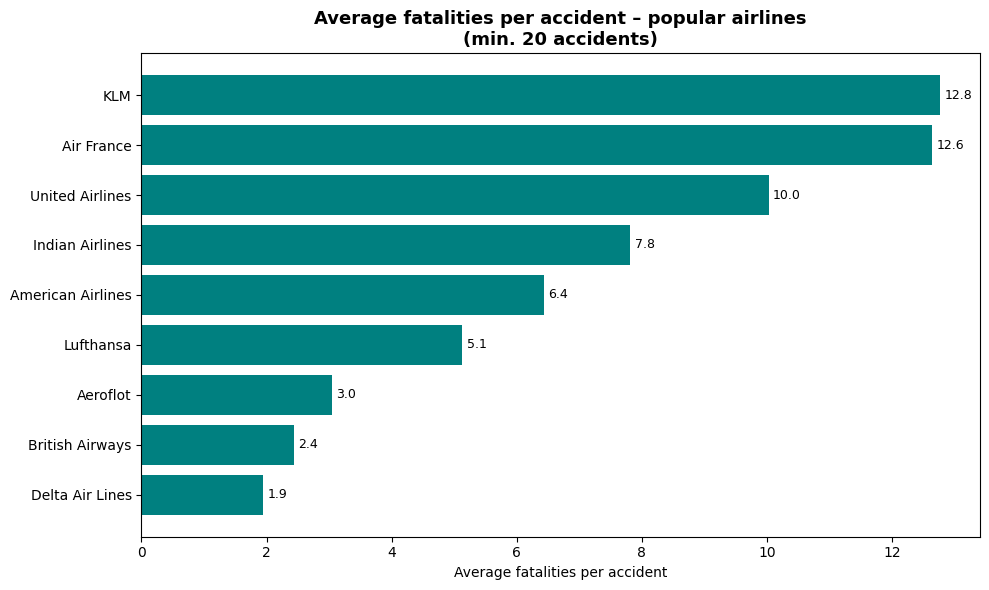

In [ ]:
# groupby airline and calculate:
#   - accidents: accidents per airline
#   - mean_fatalities: fatalities average per accident
# The filter "incidents >= 20" excludes airlines with little amount of data.
# Use groupby
op_stats = (df.groupby("operator")
              .agg(accidents=("operator", "count"),
                   mean_fatalities=("fatalities_num", "mean"))
              .query("accidents >= 20")
              .sort_values("mean_fatalities"))

# Filter only popular commercial airlines.
# Military airlines (USAF, RAF...) work on different logics and would mislead the comparison.
popular_commercial = [
    "American Airlines", "United Airlines", "Delta Air Lines",
    "Air France", "British Airways", "Lufthansa",
    "Aeroflot", "Indian Airlines", "Japan Airlines", "KLM"
]
commercial_stats = (op_stats.loc[op_stats.index.isin(popular_commercial)]
                             .sort_values("mean_fatalities"))

# Create the chart, barh
fig, ax = plt.subplots()
bars = ax.barh(commercial_stats.index, commercial_stats["mean_fatalities"], color="teal")

# fmt='%.1f' formats values with a decimal place (ex. 45.3)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_title("Average fatalities per accident – popular airlines\n(min. 20 accidents)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Average fatalities per accident")
plt.tight_layout()
plt.show()



---



#4) Which aircrafts caused more fatalities?

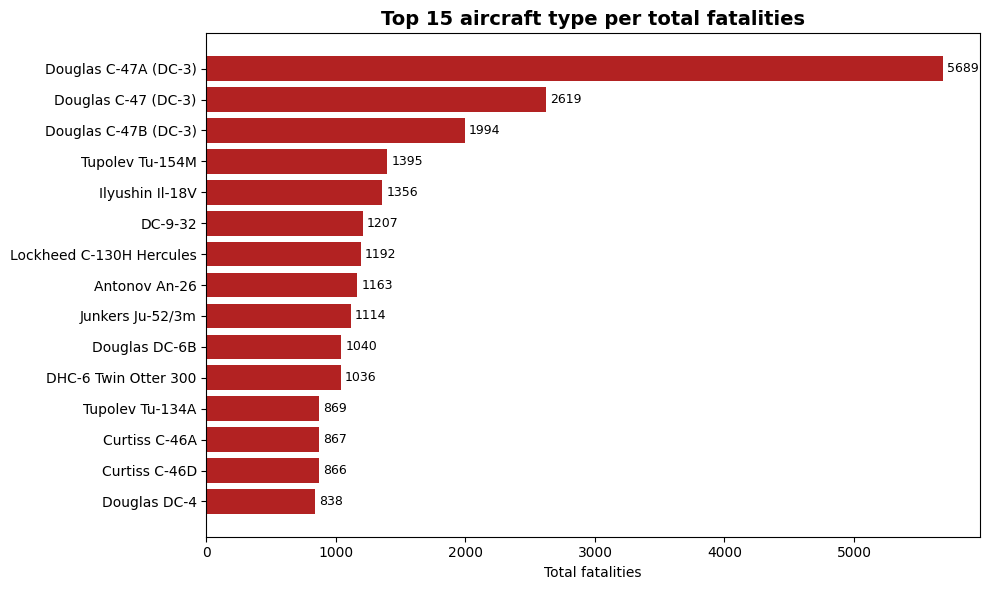

In [ ]:
# Sum fatalities for each type of aircraft and keep the top 15.
# Use .sum() instead of .mean() because i want the total absolute impact,
# not the average gravuty of singular accident.
type_deaths = (df.groupby("type")["fatalities_num"].sum().sort_values(ascending=False).head(15))


# Build the chart
fig, ax = plt.subplots()
bars = ax.barh(type_deaths.index[::-1], type_deaths.values[::-1], color="firebrick")

# fmt="%.0f" rounds values to the integer.
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
ax.set_title("Top 15 aircraft type per total fatalities", fontsize=14, fontweight="bold")
ax.set_xlabel("Total fatalities")
plt.tight_layout()
plt.show()



---



#5) What changed after 9/11?

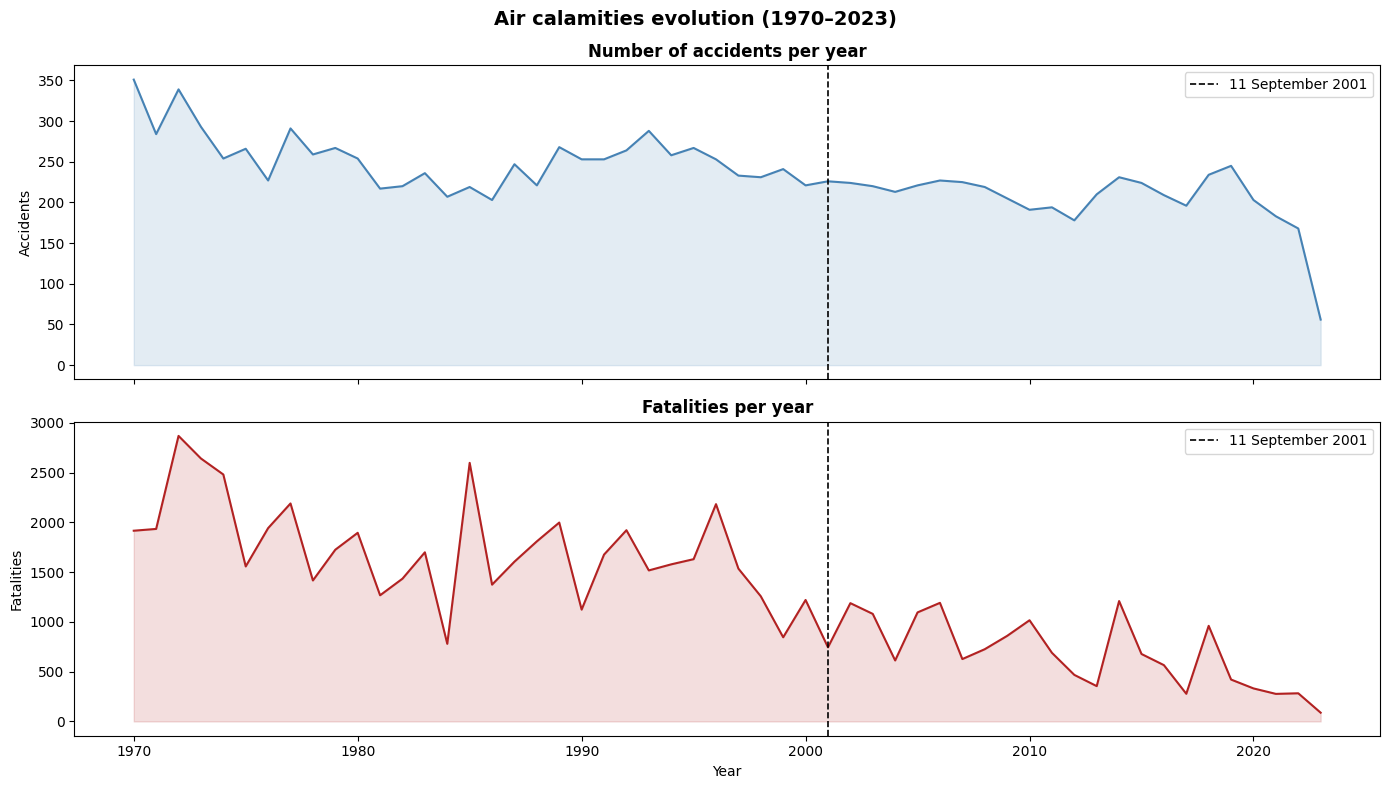

Yearly average 1991–2000: {'accidents': 250.9, 'fatalities': 1537.2}
Yearly average 2002–2011: {'accidents': 213.9, 'fatalities': 909.1}


In [ ]:
# Filter from 1970 onwards to focus on civil aviation modern era and exclude Second World War data.
# Group by year and calculate the total of accidents and fatalities each year.
yearly = (df[df["year_num"].notna() & (df["year_num"] >= 1970)]
          .groupby("year_num")
          .agg(accidents=("year_num", "count"),
               fatalities=("fatalities_num", "sum"))
          .reset_index())  # return year_num from index to normal column.



# Create a chart with two overlapping panels with shared X axis.
# The first one shows the numeber of accidents, the second one the number of fatalities.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, col, color, title in zip(
    axes,
    ["accidents", "fatalities"],
    ["steelblue", "firebrick"],
    ["Number of accidents per year", "Fatalities per year"]
):
    # Trendline
    ax.plot(yearly["year_num"], yearly[col], color=color, linewidth=1.5)

    # Colored area under the line to show clearly the "volume"
    ax.fill_between(yearly["year_num"], yearly[col], alpha=0.15, color=color)

    # Dotted vertical line to show 9/11 day.
    ax.axvline(2001, color="black", linestyle="--", linewidth=1.2, label="11 September 2001")
    ax.legend()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(col.capitalize())

axes[1].set_xlabel("Year")
plt.suptitle("Air calamities evolution (1970–2023)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Numeric comparison first/after: calculate yearly average in the previous decade and in the following one to visualize the changes.
pre_911  = yearly[yearly["year_num"].between(1991, 2000)][["accidents", "fatalities"]].mean()
post_911 = yearly[yearly["year_num"].between(2002, 2011)][["accidents", "fatalities"]].mean()
print("Yearly average 1991–2000:", pre_911.round(1).to_dict())
print("Yearly average 2002–2011:", post_911.round(1).to_dict())



---



#6) Season: in which seasons occur the highest amount of accidents?

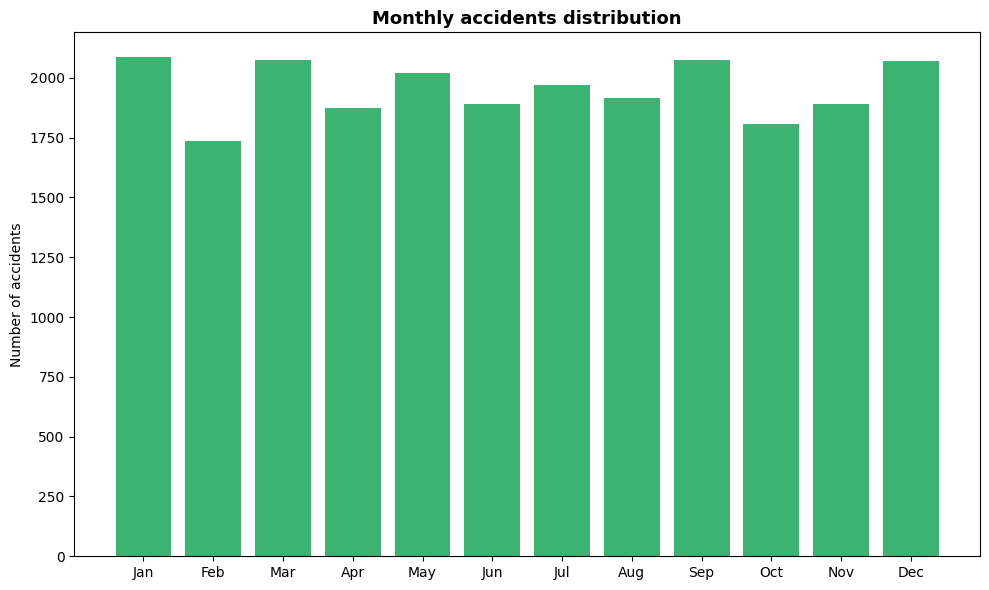

In [ ]:
# Month tickets for X axis.
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# .value_counts() counts accidents for number of the month (1–12), then .sort_index() reorders them in cronologic order (january → december).
monthly = df["month"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(month_labels, monthly.values, color="mediumseagreen")
ax.set_title("Monthly accidents distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of accidents")
plt.tight_layout()
plt.show()



---



#7) Has average mortality improved over time?

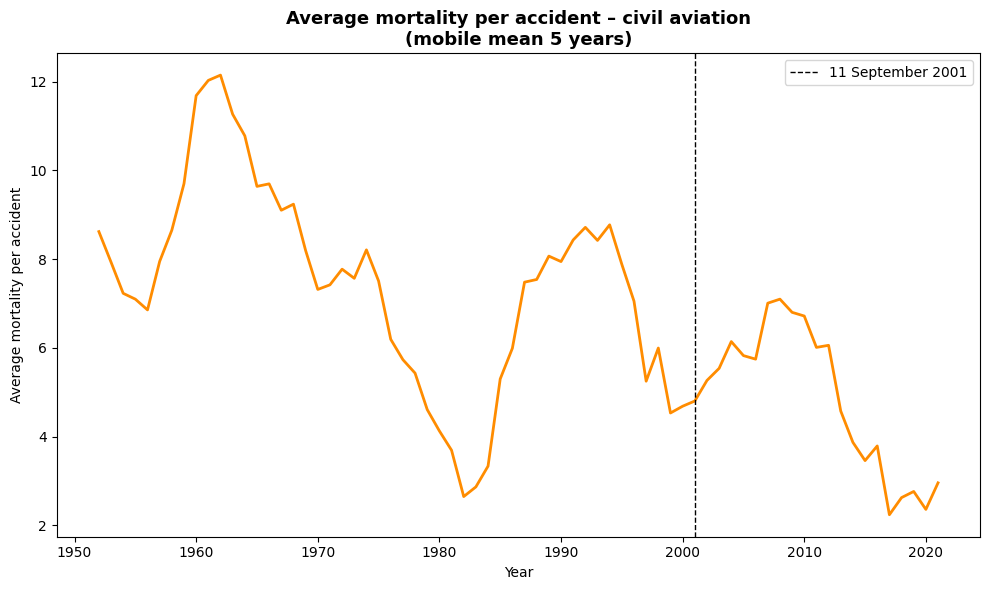

In [ ]:
# Filter only civil airlines using a testual research on column "operator".
# str.contains() accepts regular exceptions: the | works as OR.
# na=False avoids errors on NaN values on operator column.
mask = df["operator"].str.contains("Airlines|Airways|Air ", case=False, na=False)
civil = df[mask & df["year_num"].notna() & (df["year_num"] >= 1950)]

# Calculate average mortality per accident year by year, then apply a mobile mean on 5 years (rolling window) to visualize clearly the long period trend.
mortality_trend = (civil.groupby("year_num")["fatalities_num"]
                        .mean()
                        .rolling(5, center=True)
                        .mean())

# Create a line chart that shows average mortality's trend over the time.
fig, ax = plt.subplots()
ax.plot(mortality_trend.index, mortality_trend.values, color="darkorange", linewidth=2)
ax.axvline(2001, color="black", linestyle="--", linewidth=1, label="11 September 2001")
ax.set_title("Average mortality per accident – civil aviation\n(mobile mean 5 years)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Average mortality per accident")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.show()



---



#8) Distribution per accident's category

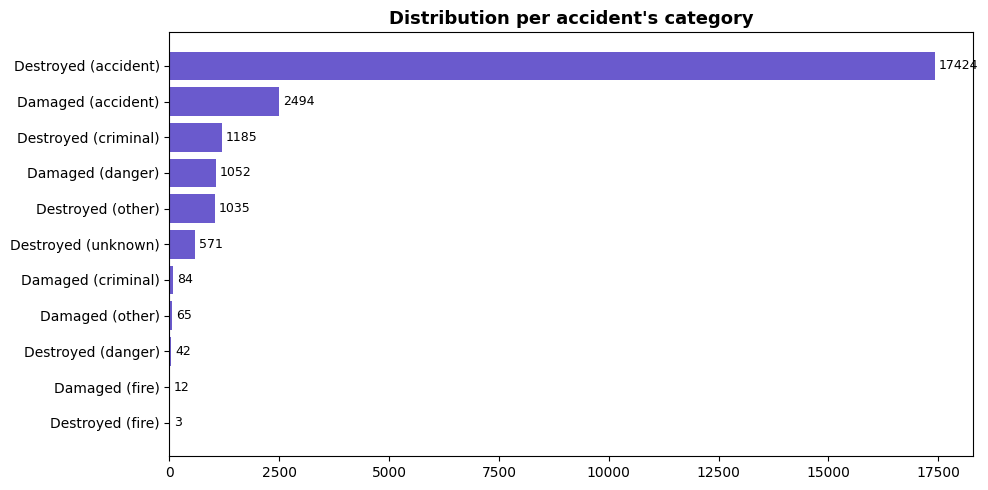

In [ ]:
# Count how many accidents belong to each category (clear tickets already).
# It's possible to visualize data about accidents: how many accidental, criminals, unknown, ecc.
cat_counts = df["cat_label"].value_counts()

# Create a orizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color="slateblue")

# ax.containers[0] is the first and only group of bars in the chart, equals to use directly the variable "bars" as in other charts.
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title("Distribution per accident's category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



---



#9) Accidents per nation (cartogram)

In [ ]:
import plotly.express as px
import numpy as np

countries = (df[df["country"] != "Unknown country"]
             ["country"].value_counts()
             .reset_index())
countries.columns = ["country", "accidents"]


# Rename cases that Plotly doesn't recognize with locationmode="country names"
countries["country"] = countries["country"].replace({
    "USA":   "United States",
    "U.K.":  "United Kingdom",
})

# Log scale to manage the big imbalance between USA and the others.
countries["log_accidents"] = np.log10(countries["accidents"])
# Create the map
fig = px.choropleth(
    countries,
    locations="country",
    locationmode="country names",
    color="log_accidents",
    color_continuous_scale="Plasma",
    title="Air calamities per nation",
    hover_name="country",
    hover_data={"accidents": ":,", "log_accidents": False},
)

# Colorbar con valori reali invece dei valori log
max_val = countries["accidents"].max()

fig.update_layout(coloraxis_colorbar=dict(
    title="Accidents",
    tickvals=[0, 1, 2, 3, np.log10(max_val)],
    ticktext=["1", "10", "100", "1.000", f"{max_val:,}"],
))


fig.show()